## Predicting LOF based on data

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metabolites_classifier import MetaboliteConditionClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc, RocCurveDisplay

df = pd.read_csv("data1.csv")
# Use LOF as target: expose as Condition_mapped so we can reuse MetaboliteConditionClassifier
df_ml = df.dropna(subset=["LOF"]).copy()
df_ml["Condition_mapped"] = df_ml["LOF"].astype(int).astype(str)
print("Shape:", df_ml.shape)
print("\nLOF (target) value counts:")
print(df_ml["Condition_mapped"].value_counts().sort_index())

Shape: (38, 72)

LOF (target) value counts:
Condition_mapped
0    28
1    10
Name: count, dtype: int64


In [20]:
# Same feature columns as main analysis: age + Z-score metabolites
z_cols = [c for c in df_ml.columns if c.startswith("Z") and len(c) > 1]
feature_cols = (["ageatcollection"] if "ageatcollection" in df_ml.columns else []) + z_cols
feature_cols = [c for c in feature_cols if c in df_ml.columns]
numeric_df = df_ml[feature_cols].apply(pd.to_numeric, errors="coerce")
print("Number of features:", len(feature_cols))
print("Sample:", feature_cols[:4], "...", feature_cols[-2:])

Number of features: 21
Sample: ['ageatcollection', 'ZLACTIC', 'Z@2OHBUT', 'Z@3OHBUT'] ... ['Z@2MECITRIC', 'Z@2KETOGLUTARIC']


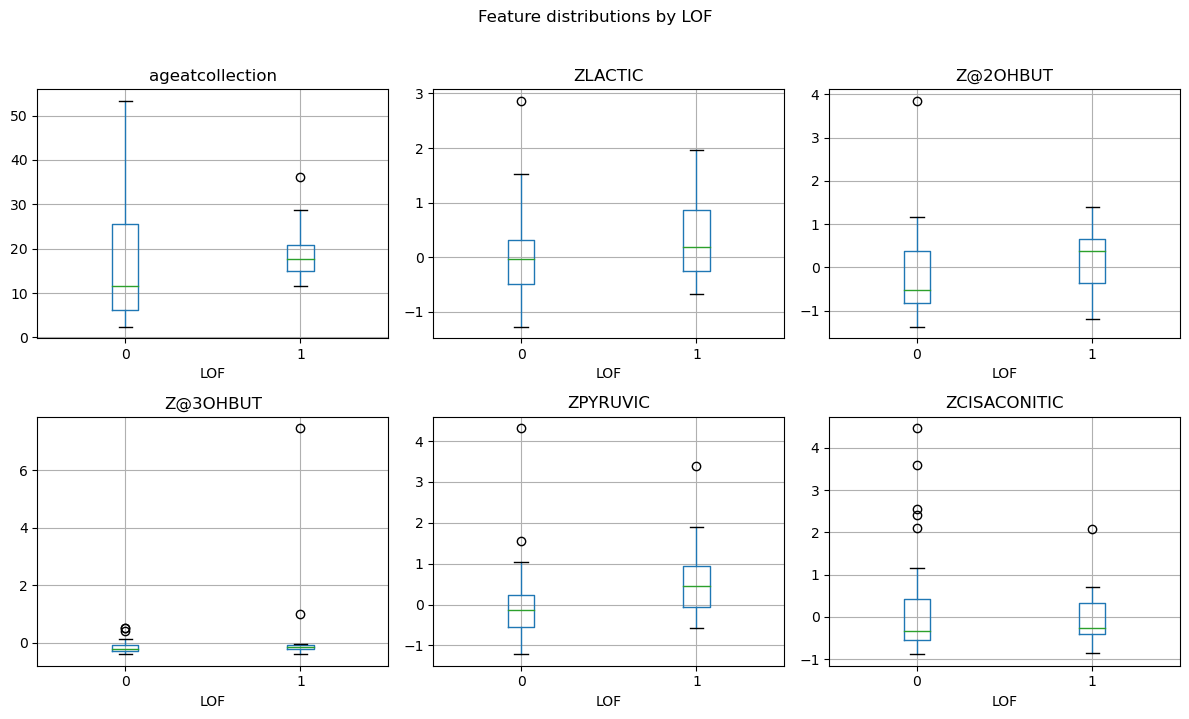

In [21]:
# EDA: distributions of selected features by LOF
plot_df = df_ml.copy()
for c in feature_cols[:6]:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for i, col in enumerate(feature_cols[:6]):
    plot_df.boxplot(column=col, by="Condition_mapped", ax=axes[i])
    axes[i].set_xlabel("LOF")
    axes[i].set_title(col)
plt.suptitle("Feature distributions by LOF", y=1.02)
plt.tight_layout()
plt.show()

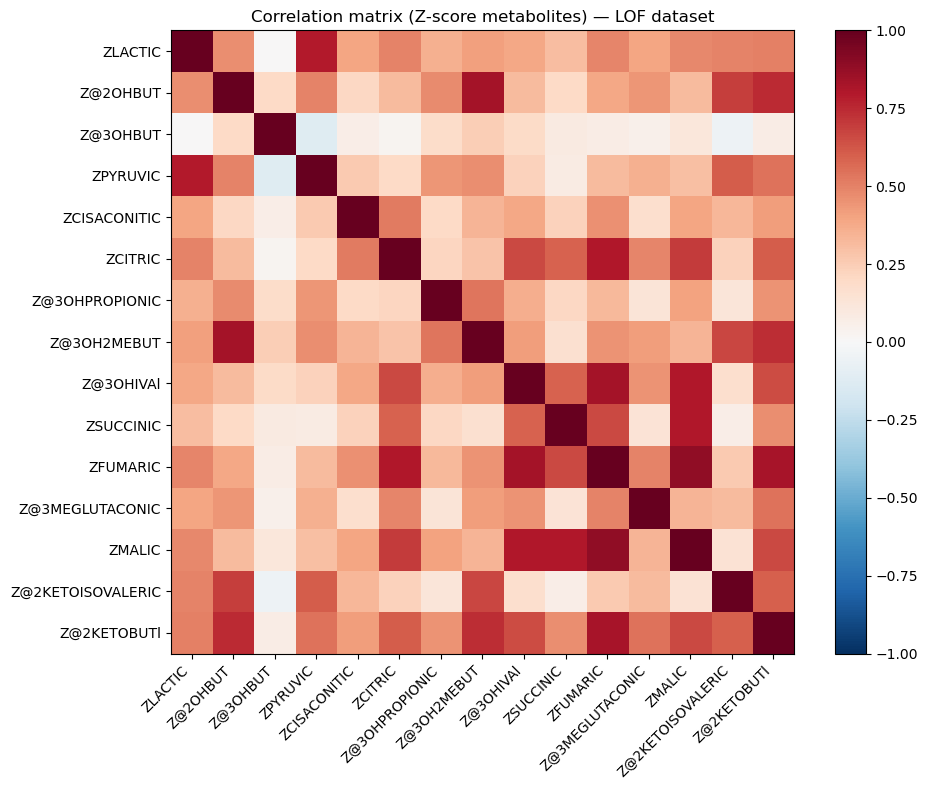

In [22]:
# Correlation matrix of Z-score metabolites
corr_cols = [c for c in feature_cols if c.startswith("Z")][:15]
corr_df = numeric_df[corr_cols].dropna(how="all")
if len(corr_df) > 0:
    corr = corr_df.corr()
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation matrix (Z-score metabolites) — LOF dataset")
    plt.tight_layout()
    plt.show()

In [23]:
# Train/test split and run all models (same API as Condition classifier; target is LOF via Condition_mapped)
clf = MetaboliteConditionClassifier(df_ml, feature_set="zscore", test_size=0.25, random_state=42)
clf.prepare_data()
results = clf.run_models(include_xgb=True, verbose=True)
results_df = pd.DataFrame(results)
print("\nSummary:")
print(results_df[["Model", "CV Accuracy (mean)", "CV std", "Test Accuracy"]])


--- Logistic Regression ---
CV accuracy: 0.760 (+/- 0.131)
Test accuracy: 0.800
              precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.67      0.67      0.67         3

    accuracy                           0.80        10
   macro avg       0.76      0.76      0.76        10
weighted avg       0.80      0.80      0.80        10


--- Random Forest ---
CV accuracy: 0.760 (+/- 0.168)
Test accuracy: 0.800
              precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       1.00      0.33      0.50         3

    accuracy                           0.80        10
   macro avg       0.89      0.67      0.69        10
weighted avg       0.84      0.80      0.76        10


--- SVM (RBF) ---
CV accuracy: 0.753 (+/- 0.072)
Test accuracy: 0.700
              precision    recall  f1-score   support

           0       0.70      1.00      0.82         7
          


--- XGBoost ---
CV accuracy: 0.820 (+/- 0.016)
Test accuracy: 0.800
              precision    recall  f1-score   support

           0       0.78      1.00      0.88         7
           1       1.00      0.33      0.50         3

    accuracy                           0.80        10
   macro avg       0.89      0.67      0.69        10
weighted avg       0.84      0.80      0.76        10


Summary:
                 Model  CV Accuracy (mean)    CV std  Test Accuracy
0  Logistic Regression            0.760000  0.130639            0.8
1        Random Forest            0.760000  0.167862            0.8
2            SVM (RBF)            0.753333  0.071802            0.7
3  K-Nearest Neighbors            0.686667  0.110755            0.7
4        Decision Tree            0.686667  0.185712            0.8
5              XGBoost            0.820000  0.016330            0.8


## Publication figures (LOF prediction)

The following figures are saved to `figures/` at 300 DPI for publication.

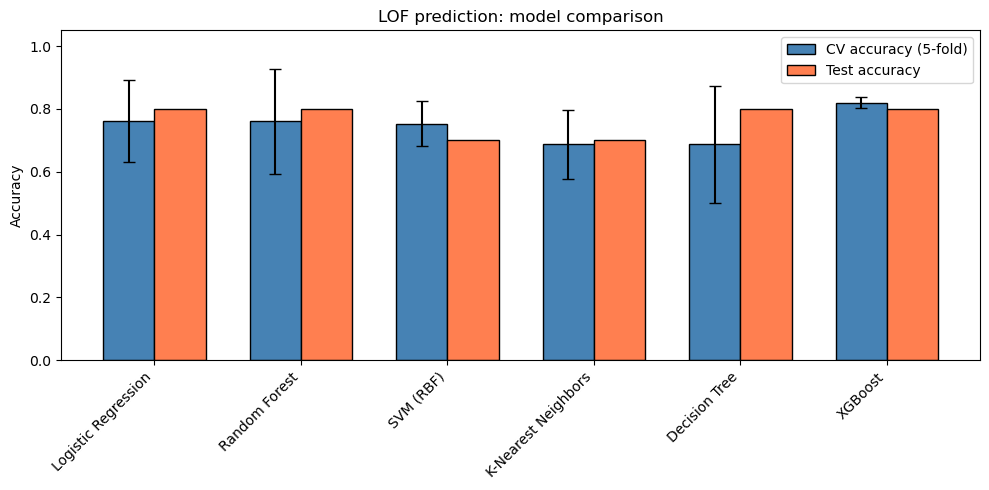

In [24]:
# Model comparison bar chart
import os
os.makedirs("figures", exist_ok=True)
x = np.arange(len(results_df))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, results_df["CV Accuracy (mean)"], width, yerr=results_df["CV std"], label="CV accuracy (5-fold)", capsize=4, color="steelblue", edgecolor="black")
ax.bar(x + width/2, results_df["Test Accuracy"], width, label="Test accuracy", color="coral", edgecolor="black")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1.05)
ax.set_title("LOF prediction: model comparison")
plt.tight_layout()
fig.savefig("figures/lof_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

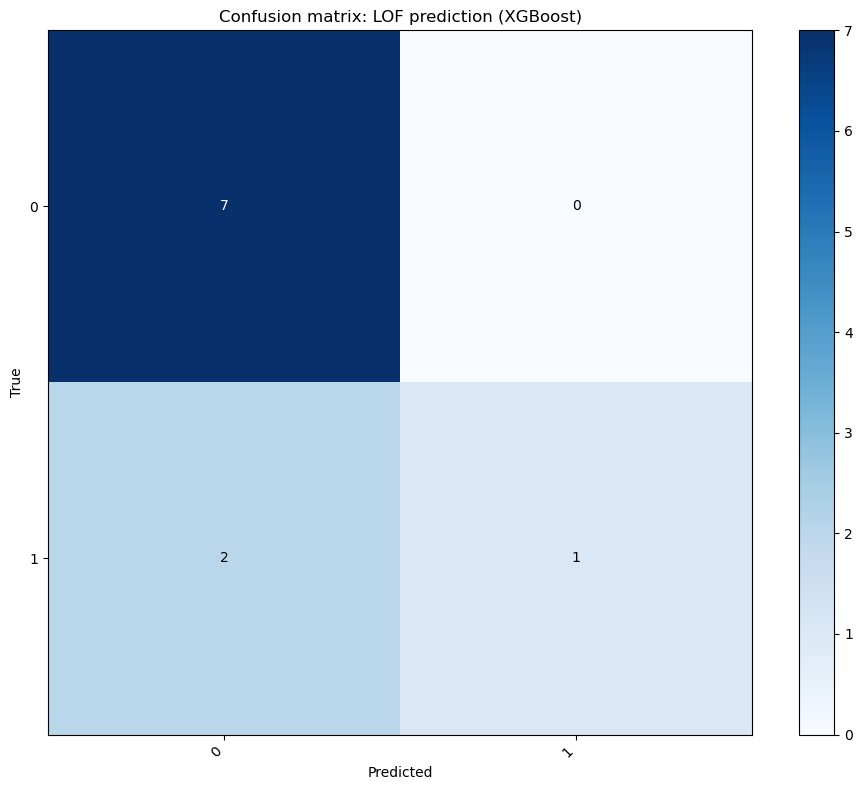

In [25]:
# Confusion matrix for XGBoost (best performer for LOF)
clf.confusion_matrix_plot("XGBoost")
plt.title("Confusion matrix: LOF prediction (XGBoost)")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.gcf().savefig("figures/lof_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

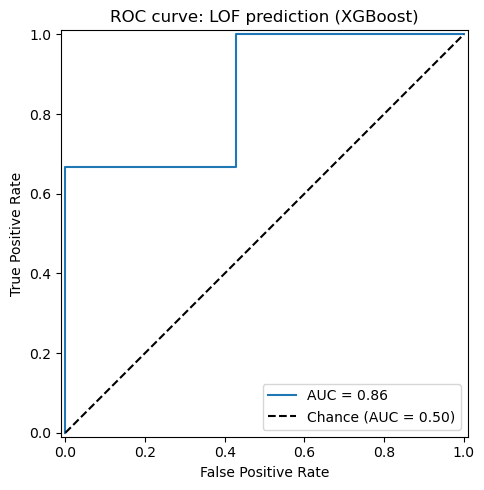

AUC: 0.857


In [26]:
# ROC curve (binary: LOF=1 vs LOF=0) — XGBoost
from xgboost import XGBClassifier
y_train_int = clf.label_encoder_.transform(clf.y_train_)
xgb = XGBClassifier(random_state=42, eval_metric="logloss")
xgb.fit(clf.X_train_s_, y_train_int)
# predict_proba columns match label_encoder_.classes_ (e.g. ["0","1"]); use column for "1"
pos_idx = list(clf.label_encoder_.classes_).index("1")
y_score = xgb.predict_proba(clf.X_test_s_)[:, pos_idx]
fpr, tpr, _ = roc_curve(clf.y_test_, y_score, pos_label="1")
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.50)")
ax.set_title("ROC curve: LOF prediction (XGBoost)")
ax.legend(loc="lower right")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/lof_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print("AUC:", round(roc_auc, 3))

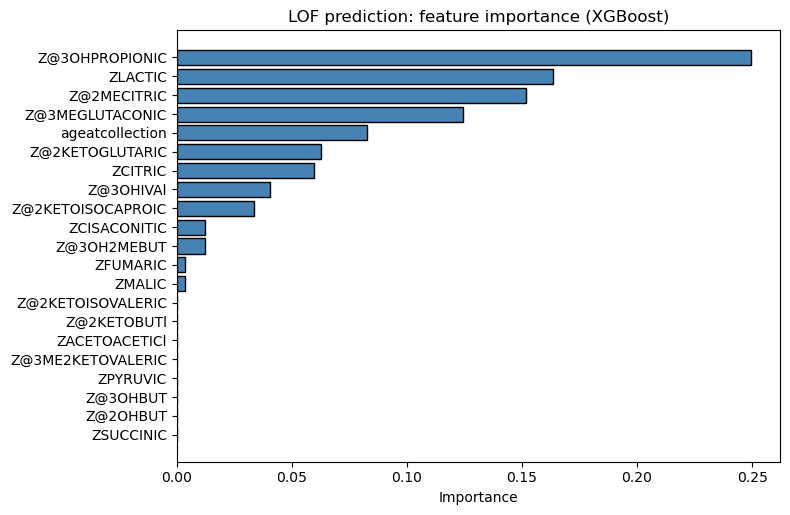

In [27]:
# Feature importance (XGBoost)
imp = xgb.feature_importances_
names = clf.get_feature_columns()
order = np.argsort(imp)[::-1]
imp = imp[order]
names = [names[i] for i in order]
fig, ax = plt.subplots(figsize=(8, max(4, len(names) * 0.25)))
ax.barh(range(len(names)), imp, color="steelblue", edgecolor="black")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel("Importance")
ax.set_title("LOF prediction: feature importance (XGBoost)")
ax.invert_yaxis()
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/lof_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()